In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rioxarray  # for spatial plotting compatibility
import os


In [6]:
# Load and average each year's file over time
diff_dir = "/global/scratch/users/yougsanghvi/era5_gdnat_panel_diff/"
years = range(2000, 2005)

diff_yearly_mean = []
for year in years:
    path = os.path.join(diff_dir, f"era5_gdnat_diff_{year}.nc")
    ds = xr.open_dataset(path)
    var_name = list(ds.data_vars)[0]  # e.g., 't2m'
    da = ds[var_name]

    # Optional: normalize longitude to [-180, 180]
    if da.longitude.max() > 180:
        da = da.assign_coords(longitude=(((da.longitude + 180) % 360) - 180)).sortby('longitude')

    # Average over time (days) to get a spatial bias map for this year
    da_mean = da.mean(dim="time")
    diff_yearly_mean.append(da_mean)

# Stack along 'year' and compute average bias over 2000–2004
diff_avg = xr.concat(diff_yearly_mean, dim="year").mean(dim="year")


/tmp/ipykernel_675865/1539866855.py:8: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/tmp/ipykernel_675865/1539866855.py:8: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/tmp/ipykernel_675865/1539866855.py:8: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/tmp/ipykernel_675865/1539866855.py:8: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False,

In [8]:
# Define paths for usa county shapefile
usa_county_dir = os.path.join("/global/scratch/users/yougsanghvi", "shapefiles")
usa_county_filename = "tl_2016_us_county_mortality.shp"
usa_county_path = os.path.join(usa_county_dir, usa_county_filename)

# Loading in county shapefile
usa_counties = gpd.read_file(usa_county_path)

In [15]:
diff_avg

<xarray.DataArray '__xarray_dataarray_variable__' (latitude: 720,
                                                   longitude: 1440)> Size: 4MB
array([[1.246634 , 1.2455399, 1.2455429, ..., 1.246876 , 1.2468786,
        1.24675  ],
       [1.2486796, 1.2475541, 1.2472166, ..., 1.2485733, 1.24867  ,
        1.2486811],
       [1.2476923, 1.2460736, 1.24595  , ..., 1.2480737, 1.2476611,
        1.2477624],
       ...,
       [1.0157032, 1.0156085, 1.0158302, ..., 1.0157459, 1.0158741,
        1.0157458],
       [1.016649 , 1.016863 , 1.0165898, ..., 1.0164806, 1.0166117,
        1.0169189],
       [1.0469301, 1.0469301, 1.0469301, ..., 1.0469301, 1.0469301,
        1.0469301]], shape=(720, 1440), dtype=float32)
Coordinates:
  * latitude     (latitude) float64 6kB 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
    number       int64 8B 0
    step         timedelta64[ns] 8B 00:00:00
    surface      float64 8B 0.0
  * longitude    (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    spatial_ref  int64 8B 0

In [16]:
diff_avg_usa = diff_avg.sel(
    latitude=slice(50, 24),         # North to South
    longitude=slice(-130, -65)      # West to East
)


In [17]:
diff_avg_usa

<xarray.DataArray '__xarray_dataarray_variable__' (latitude: 105, longitude: 261)> Size: 110kB
array([[0.26353574, 0.26103774, 0.26088658, ..., 0.2428673 , 0.24365327,
        0.24118367],
       [0.26489776, 0.2642356 , 0.26313102, ..., 0.10241678, 0.10307769,
        0.10366572],
       [0.26557356, 0.26539263, 0.26491156, ..., 0.10655488, 0.10709314,
        0.10765646],
       ...,
       [0.28483963, 0.28593022, 0.28529686, ..., 0.62468404, 0.6250211 ,
        0.62480396],
       [0.28471684, 0.285024  , 0.28468275, ..., 0.6252183 , 0.62510455,
        0.62479246],
       [0.2838765 , 0.28411937, 0.2843089 , ..., 0.6242165 , 0.62483007,
        0.62454367]], shape=(105, 261), dtype=float32)
Coordinates:
  * latitude     (latitude) float64 840B 50.0 49.75 49.5 ... 24.5 24.25 24.0
    number       int64 8B 0
    step         timedelta64[ns] 8B 00:00:00
    surface      float64 8B 0.0
  * longitude    (longitude) float64 2kB -130.0 -129.8 -129.5 ... -65.25 -65.0
    spatial_ref  int64 8B 0

ERROR 1: PROJ: internal_proj_create_from_database: /global/software/rocky-8.x86_64/gcc/linux-rocky8-x86_64/gcc-11.4.0/proj-9.2.1-bbhelefiajxgp4kdvlkru6cicfl3ty5t/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.


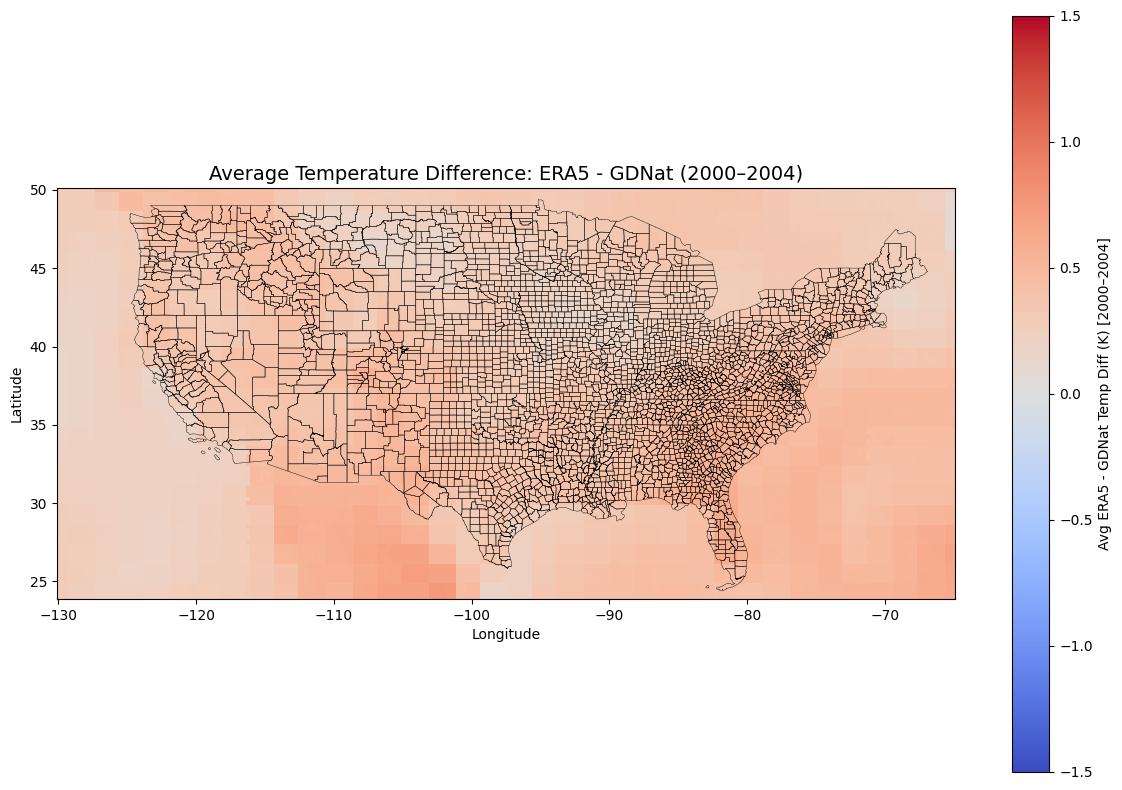

In [19]:

# 3. Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# Tag CRS for rioxarray (required for overlay)
diff_avg_usa.rio.write_crs("EPSG:4326", inplace=True)

# Plot raster
diff_avg_usa.plot(
    ax=ax,
    cmap="coolwarm",
    vmin=-1.5, vmax=1.5,  # Adjust limits for better contrast
    cbar_kwargs={"label": "Avg ERA5 - GDNat Temp Diff (K) [2000–2004]"}
)

# Plot county borders
usa_counties.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.3)

ax.set_title("Average Temperature Difference: ERA5 - GDNat (2000–2004)", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()
